# 38_DINOv3_ViTL16_FullFineTune_Holdout_E2E

DINOv3 ViT-L/16 LVD-1689M; full fine-tuning, learning rate backbone kecil, gradient checkpointing. Sumber: https://huggingface.co/timm/vit_large_patch16_dinov3.lvd1689m

**Mandiri:** jalankan Run All pada kernel PyTorch CUDA; hanya dataset, library terpasang, dan bobot dasar pretrained yang dibaca. Tidak ada import script proyek atau load artifact eksperimen.

**Smoke default:** `SMOKE_TEST=True` menjalankan tepat satu epoch pada seluruh train split, validasi lengkap, dan inferensi seluruh test. Untuk eksperimen penuh, ubah `SMOKE_TEST=False` lalu Restart Kernel & Run All. Skor smoke bukan perbandingan model terkonvergensi.

Holdout stratified 80:20 seed 42 sama untuk semua notebook; tidak memakai K-fold. Kanvas 160×640, grayscale tiga kanal, normalisasi ImageNet, augmentasi sama. Cost-sensitive CE inverse akar frekuensi + pengali Jawi/Pegon 1,5, hanya dihitung dari train split. Split belum merupakan validasi lintas buku dan kemiripan nonidentik dapat melintasinya. Label test tidak dibaca.

Dependensi: torch, torchvision, numpy, pandas, Pillow, scikit-learn, matplotlib; DINOv3 memakai timm>=1.0.27 serta akses bobot Hub. Output run dibuat pada `exp/results/`, termasuk submission model holdout. Default 40 epoch bukan jaminan konvergensi ResNet scratch; LR backbone berbeda sesuai inisialisasi.

In [1]:
import os
os.environ['PYTHONHASHSEED'] = '42'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
from pathlib import Path
from copy import deepcopy
from contextlib import nullcontext
import gc, hashlib, json, math, random, time, platform
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

ROOT = Path(r"E:\datsci\infest_usk")  # Ubah hanya lokasi dataset jika dipindah.
SMOKE_TEST = False  # True: 1 epoch penuh. Ubah False untuk training penuh.
FULL_EPOCHS, PATIENCE = 40, 8
SEED, VAL_FRACTION = 42, 0.20
HEIGHT, WIDTH = 160, 640
EFFECTIVE_BATCH, JP_COST = 32, 1.5
WEIGHT_DECAY, WARMUP_EPOCHS = 1e-4, 3
RUN_TEST_INFERENCE = True  # Submission dari checkpoint holdout di memori; tanpa retrain seluruh data.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DEVICE.type == 'cuda', 'Pilih kernel PyTorch CUDA sebelum Run All.'
AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
LABELS = ['bali','jawa','jawi','lampung','lontara','pegon','sunda']
LABEL_TO_ID = {label:i for i,label in enumerate(LABELS)}

def seed_all():
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
seed_all()
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True, warn_only=False)
torch.set_deterministic_debug_mode('error')
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

def sha256(path): return hashlib.sha256(Path(path).read_bytes()).hexdigest()
def digest_ids(ids): return hashlib.sha256('\n'.join(sorted(ids)).encode()).hexdigest()

MODEL_NAME='dinov3_vitl16_fullft'
MICRO_BATCH=2
BACKBONE_LR,HEAD_LR=1e-05,0.0003
print(MODEL_NAME,DEVICE,torch.cuda.get_device_name(),flush=True)

dinov3_vitl16_fullft cuda NVIDIA GeForce RTX 5060 Ti


In [2]:
# Membaca CSV dan setiap gambar langsung dari dataset, tanpa manifest/artifact eksternal.
train_csv, test_csv = ROOT/'data/train.csv', ROOT/'data/test.csv'
train_raw, test = pd.read_csv(train_csv), pd.read_csv(test_csv)
assert set(train_raw.columns)=={'image_id','label'} and set(test.columns)=={'image_id'}
assert train_raw.notna().all().all() and test.notna().all().all()
assert train_raw.image_id.is_unique and test.image_id.is_unique
assert set(train_raw.label)==set(LABELS)
assert not (set(train_raw.image_id)&set(test.image_id)), 'ID train/test bertumpang tindih.'

def open_gray(path):
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image).convert('RGBA')
        white = Image.new('RGBA',image.size,'white')
        return Image.alpha_composite(white,image).convert('L')

valid, bad, test_meta, image_cache = [], [], [], {}
for subset, frame in [('train',train_raw),('test',test)]:
    for row in frame.to_dict('records'):
        path = ROOT/'images'/subset/row['image_id']
        assert Path(row['image_id']).name==row['image_id'], 'image_id harus berupa nama file.'
        try:
            gray = open_gray(path)
            width,height = gray.size
            record = dict(row,width=width,height=height,ratio=width/height,sha256=sha256(path))
            (valid if subset=='train' else test_meta).append(record)
            # Cache preprocessing dibuat ulang dari gambar pada run ini; tidak load cache/artifact lama.
            scale=min(HEIGHT/height,WIDTH/width)
            image_cache[(subset,row['image_id'])]=gray.resize((max(1,round(width*scale)),max(1,round(height*scale))),Image.Resampling.BICUBIC)
        except (OSError,ValueError) as error:
            if subset=='test': raise RuntimeError(f'Gambar test gagal dibaca: {path}') from error
            bad.append({'image_id':row['image_id'],'reason':str(error)})
train = pd.DataFrame(valid)
test_info = pd.DataFrame(test_meta)
assert len(train)>0 and len(test_info)==len(test)
train_indices,val_indices = train_test_split(np.arange(len(train)),test_size=VAL_FRACTION,random_state=SEED,stratify=train.label)
train_part,val_part=train.iloc[train_indices].reset_index(drop=True),train.iloc[val_indices].reset_index(drop=True)
assert set(train_part.label)==set(val_part.label)==set(LABELS)
assert not(set(train_part.image_id)&set(val_part.image_id))
validation_duplicate_hashes = set(train_part.sha256)&set(val_part.sha256)
assert not validation_duplicate_hashes, 'Gambar identik melintasi holdout: perbaiki split sebelum training.'
train_test_duplicate_hashes=set(train.sha256)&set(test_info.sha256)
split_hash=digest_ids(val_part.image_id)
dataset_signature=hashlib.sha256((sha256(train_csv)+sha256(test_csv)+''.join(train.sha256)+''.join(test_info.sha256)).encode()).hexdigest()
print({'train_valid':len(train),'test':len(test),'dropped':bad,'train_test_identical_hashes':len(train_test_duplicate_hashes),'holdout_hash':split_hash},flush=True)
display(pd.DataFrame({'total':train.label.value_counts(),'train':train_part.label.value_counts(),'validation':val_part.label.value_counts()}).reindex(LABELS))
display(train.groupby('label')[['width','height','ratio']].median().reindex(LABELS))

{'train_valid': 3771, 'test': 1220, 'dropped': [], 'train_test_identical_hashes': 2, 'holdout_hash': '2a50b2643399410ecfb39d2ec0fb71af884bb715aa406e07d7bad96c6d9457be'}


,total,train,validation
label,,,
bali,396,317,79
jawa,703,562,141
jawi,781,625,156
lampung,505,404,101
lontara,404,323,81
pegon,309,247,62
sunda,673,538,135


,width,height,ratio
label,,,
bali,1350.0,66.0,19.185714
jawa,712.0,75.0,9.530612
jawi,391.0,64.0,6.054795
lampung,148.0,42.0,3.337662
lontara,935.0,53.0,16.875000
pegon,159.0,123.0,1.158940
sunda,182.0,54.0,3.513514


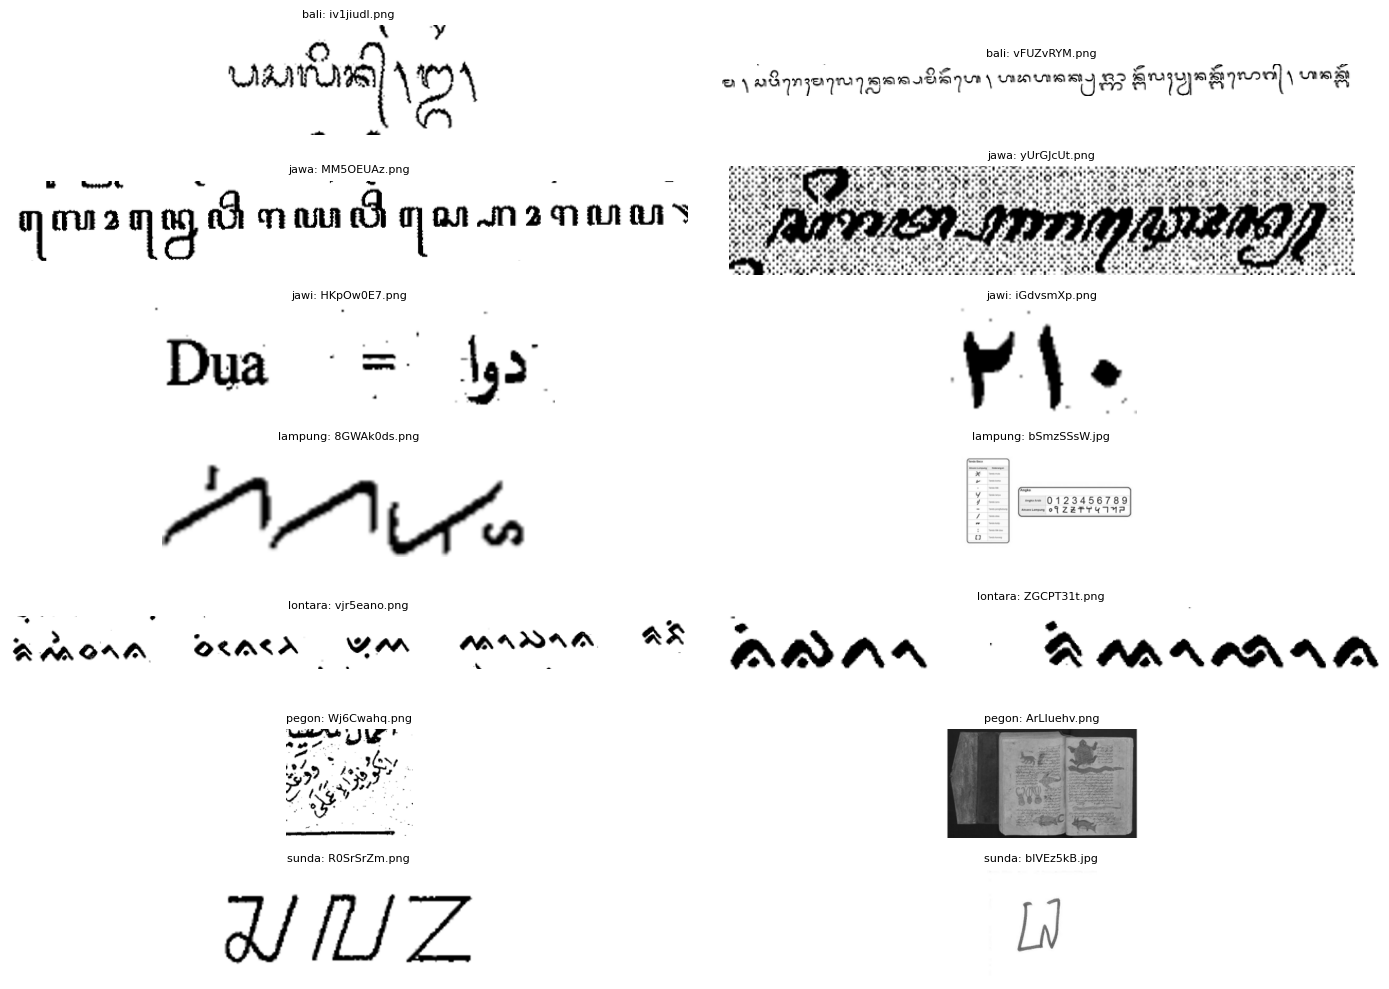

Data pipeline lulus; batch efektif 32


In [3]:
MEAN=torch.tensor([0.485,0.456,0.406]).view(3,1,1)
STD=torch.tensor([0.229,0.224,0.225]).view(3,1,1)

def make_tensor(gray, augment=False):
    image=gray.copy()
    if augment:
        # expand=True mempertahankan goresan saat rotasi; fit ulang menjaga seluruh gambar.
        image=image.rotate(random.uniform(-3,3),resample=Image.Resampling.BICUBIC,expand=True,fillcolor=255)
        image=ImageEnhance.Contrast(image).enhance(random.uniform(0.9,1.1))
        image=ImageEnhance.Brightness(image).enhance(random.uniform(0.9,1.1))
        if random.random()<0.1: image=image.filter(ImageFilter.GaussianBlur(random.uniform(0.1,0.5)))
    if image.width>WIDTH or image.height>HEIGHT:
        image.thumbnail((WIDTH,HEIGHT),Image.Resampling.BICUBIC)
    canvas=Image.new('L',(WIDTH,HEIGHT),255)
    canvas.paste(image,((WIDTH-image.width)//2,(HEIGHT-image.height)//2))
    tensor=torch.from_numpy(np.array(canvas,copy=True)).float().unsqueeze(0).repeat(3,1,1)/255
    return (tensor-MEAN)/STD

class ScriptDataset(Dataset):
    def __init__(self,frame,subset='train',augment=False): self.frame,self.subset,self.augment=frame.reset_index(drop=True),subset,augment
    def __len__(self): return len(self.frame)
    def __getitem__(self,index):
        row=self.frame.iloc[index]
        tensor=make_tensor(image_cache[(self.subset,row.image_id)],self.augment)
        label=LABEL_TO_ID[row.label] if 'label' in self.frame.columns else -1
        return tensor,label,row.image_id

# Preprocessing seluruh dimensi ekstrem diuji dari cache dataset.
for i in [train.ratio.idxmin(),train.ratio.idxmax(),train.height.idxmax()]:
    value=make_tensor(image_cache[('train',train.iloc[i].image_id)],True)
    assert value.shape==(3,HEIGHT,WIDTH) and torch.isfinite(value).all()
fig,axes=plt.subplots(7,2,figsize=(14,10))
for i,label in enumerate(LABELS):
    sample=train_part[train_part.label==label].sample(2,random_state=SEED)
    for axis,row in zip(axes[i],sample.itertuples()):
        axis.imshow(image_cache[('train',row.image_id)],cmap='gray',vmin=0,vmax=255); axis.set_title(f'{label}: {row.image_id}',fontsize=8); axis.axis('off')
plt.tight_layout(); plt.show(); plt.close(fig)

train_loader=DataLoader(ScriptDataset(train_part,augment=True),batch_size=MICRO_BATCH,shuffle=True,num_workers=0,pin_memory=True,generator=torch.Generator().manual_seed(SEED))
val_loader=DataLoader(ScriptDataset(val_part),batch_size=MICRO_BATCH,shuffle=False,num_workers=0,pin_memory=True)
assert EFFECTIVE_BATCH%MICRO_BATCH==0
ACCUMULATION=EFFECTIVE_BATCH//MICRO_BATCH
print('Data pipeline lulus; batch efektif',EFFECTIVE_BATCH,flush=True)

In [4]:
import timm
# Bobot dasar publik dari cache/Hub model diperbolehkan; tidak ada checkpoint hasil eksperimen.
model=timm.create_model('vit_large_patch16_dinov3.lvd1689m',pretrained=True,num_classes=len(LABELS),img_size=(HEIGHT,WIDTH),global_pool='token')
model.set_grad_checkpointing(True)
classifier=model.get_classifier()
model=model.to(DEVICE)
print('DINOv3 timm version:',timm.__version__,flush=True)

DINOv3 timm version: 1.0.27


In [5]:
# Semua parameter dilatih. Biaya kelas dihitung HANYA dari train_part.
assert all(p.requires_grad for p in model.parameters())
counts=train_part.label.value_counts()
cost=np.array([1/np.sqrt(counts[label]) for label in LABELS],dtype=np.float32)
for label in ['jawi','pegon']: cost[LABEL_TO_ID[label]]*=JP_COST
cost/=cost.mean()
class_cost=torch.tensor(cost,device=DEVICE)
print('Class cost:',dict(zip(LABELS,cost.tolist())),flush=True)
head_parameter_ids={id(p) for p in classifier.parameters()}
backbone=[p for p in model.parameters() if id(p) not in head_parameter_ids]
optimizer=torch.optim.AdamW([{'params':backbone,'lr':BACKBONE_LR},{'params':list(classifier.parameters()),'lr':HEAD_LR}],weight_decay=WEIGHT_DECAY,foreach=False)
updates_per_epoch=math.ceil(len(train_loader)/ACCUMULATION)
total_updates=FULL_EPOCHS*updates_per_epoch
warmup_updates=min(WARMUP_EPOCHS*updates_per_epoch,total_updates-1)
def lr_factor(step):
    if step<warmup_updates: return (step+1)/max(1,warmup_updates)
    progress=min(1.,(step-warmup_updates)/max(1,total_updates-warmup_updates))
    return 0.01+0.99*0.5*(1+math.cos(math.pi*progress))
scheduler=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_factor)
scaler=torch.amp.GradScaler('cuda',enabled=AMP_DTYPE==torch.float16)

@torch.inference_mode()
def evaluate(loader):
    model.eval(); probabilities=[]; labels=[]; ids=[]
    for images,y,names in loader:
        with torch.autocast('cuda',dtype=AMP_DTYPE): logits=model(images.to(DEVICE,non_blocking=True))
        prob=logits.float().softmax(1).cpu()
        assert torch.isfinite(prob).all() and torch.allclose(prob.sum(1),torch.ones(len(prob)),atol=1e-5)
        probabilities.append(prob.numpy()); labels.extend(y.tolist()); ids.extend(names)
    return np.concatenate(probabilities),np.array(labels),ids

# Forward awal eval agar statistik BatchNorm tidak tercemar oleh smoke check.
model.eval()
with torch.inference_mode(),torch.autocast('cuda',dtype=AMP_DTYPE):
    output=model(next(iter(val_loader))[0].to(DEVICE))
assert output.shape[1]==len(LABELS) and torch.isfinite(output).all()
del output
# Mulai RNG training ulang agar smoke dan full mempunyai epoch pertama yang sama.
seed_all()
train_loader.generator.manual_seed(SEED)
best_score=-1.; best_state=None; best_epoch=0; stale=0; history=[]
start=time.perf_counter(); torch.cuda.reset_peak_memory_stats()
RUN_EPOCHS=1 if SMOKE_TEST else FULL_EPOCHS
backbone_probe=backbone[0]; head_probe=next(classifier.parameters())
backbone_before=backbone_probe.detach().cpu().clone(); head_before=head_probe.detach().cpu().clone()
for epoch in range(1,RUN_EPOCHS+1):
    model.train(); optimizer.zero_grad(set_to_none=True); loss_sum=0.; cost_sum=0.; epoch_start=time.perf_counter()
    # Gradient weighted CE tepat untuk effective batch, termasuk batch terakhir yang pendek.
    group_denominator=0.; epoch_seen=0
    for step,(images,y,_) in enumerate(train_loader,1):
        images,y=images.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True)
        with torch.autocast('cuda',dtype=AMP_DTYPE):
            logits=model(images)
            loss=F.cross_entropy(logits.float(),y,weight=class_cost,reduction='sum')
        assert torch.isfinite(loss), 'Loss tidak finite.'
        scaler.scale(loss).backward()
        denominator=float(class_cost[y].sum())
        group_denominator+=denominator; loss_sum+=float(loss.detach()); cost_sum+=denominator; epoch_seen+=len(y)
        if step%ACCUMULATION==0 or step==len(train_loader):
            scaler.unscale_(optimizer)
            for p in model.parameters():
                if p.grad is not None: p.grad.div_(group_denominator)
            norm=torch.nn.utils.clip_grad_norm_(model.parameters(),1.,error_if_nonfinite=True)
            if epoch==1 and step==ACCUMULATION:
                assert backbone_probe.grad is not None and backbone_probe.grad.abs().sum()>0
                assert head_probe.grad is not None and head_probe.grad.abs().sum()>0
            previous_scale=scaler.get_scale(); scaler.step(optimizer); scaler.update()
            if scaler.get_scale()>=previous_scale: scheduler.step()
            optimizer.zero_grad(set_to_none=True); group_denominator=0.
        if step%100==0 or step==len(train_loader):
            print(f'epoch {epoch}: {epoch_seen}/{len(train_part)} train, loss={loss_sum/cost_sum:.4f}',flush=True)
    assert epoch_seen==len(train_part)
    probs,truth,ids=evaluate(val_loader); pred=probs.argmax(1)
    score=f1_score(truth,pred,labels=list(range(len(LABELS))),average='macro',zero_division=0)
    record={'epoch':epoch,'loss':loss_sum/cost_sum,'macro_f1':float(score),'seconds':time.perf_counter()-epoch_start,'backbone_lr':optimizer.param_groups[0]['lr']}
    history.append(record); print(json.dumps(record),flush=True)
    if score>best_score:
        best_score,best_epoch,stale=float(score),epoch,0
        best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else: stale+=1
    if epoch==1:
        assert not torch.equal(backbone_before,backbone_probe.detach().cpu()), 'Backbone tidak berubah.'
        assert not torch.equal(head_before,head_probe.detach().cpu()), 'Head tidak berubah.'
        print('SMOKE epoch 1 penuh LULUS: loss/grad finite, backbone dan head berubah, validasi lengkap.',flush=True)
    if stale>=PATIENCE: break
assert best_state is not None
training_seconds=time.perf_counter()-start
peak_vram_gb=torch.cuda.max_memory_allocated()/1024**3
model.load_state_dict(best_state); model.eval()
del optimizer,scaler,backbone_before,head_before
for p in model.parameters(): p.grad=None
gc.collect(); torch.cuda.empty_cache()

Class cost: {'bali': 0.9772853851318359, 'jawa': 0.733977735042572, 'jawi': 1.0440043210983276, 'lampung': 0.8656859397888184, 'lontara': 0.9681658744812012, 'pegon': 1.6607102155685425, 'sunda': 0.7501703500747681}


epoch 1: 200/3016 train, loss=1.9450


epoch 1: 400/3016 train, loss=1.9425


epoch 1: 600/3016 train, loss=1.9377


epoch 1: 800/3016 train, loss=1.9311


...

epoch 17: 2600/3016 train, loss=0.0002


epoch 17: 2800/3016 train, loss=0.0002


epoch 17: 3000/3016 train, loss=0.0002


epoch 17: 3016/3016 train, loss=0.0002


{"epoch": 17, "loss": 0.0001593207522106116, "macro_f1": 0.9726065349559961, "seconds": 348.609766900001, "backbone_lr": 6.895639565012528e-06}


,precision,recall,f1-score,support
bali,0.973684,0.936709,0.954839,79.000000
jawa,0.958621,0.985816,0.972028,141.000000
jawi,0.980892,0.987179,0.984026,156.000000
lampung,0.980392,0.990099,0.985222,101.000000
lontara,1.000000,0.987654,0.993789,81.000000
pegon,0.967742,0.967742,0.967742,62.000000
sunda,0.984962,0.970370,0.977612,135.000000
accuracy,0.977483,0.977483,0.977483,0.977483
macro avg,0.978042,0.975081,0.976465,755.000000
weighted avg,0.977610,0.977483,0.977454,755.000000


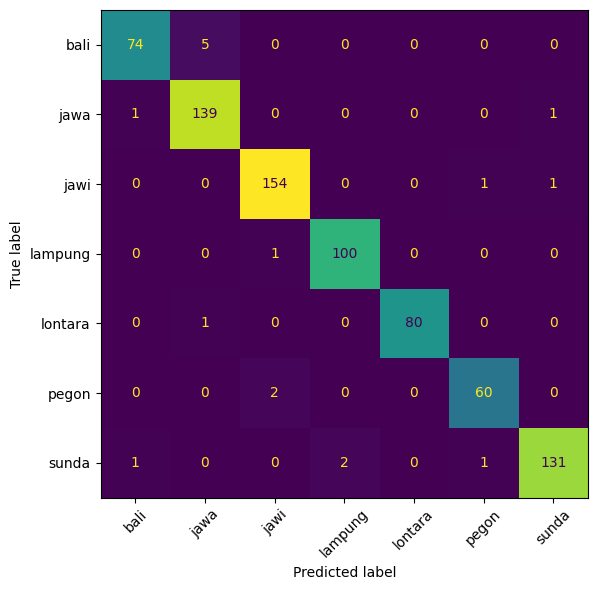

,bucket,n,macro_f1_7_classes,jawi_n,pegon_n
0,2-10,286,0.985652,65,7
1,<2,198,0.878694,52,45
2,>10,271,1.000000,39,10


{
  "model": "dinov3_vitl16_fullft",
  "smoke_test": false,
  "dataset_signature": "ba65fb413ad0bc128e6ea4d4ed35b1b44e0f4f75e934ce7850b421625789c3f1",
  "holdout_hash": "2a50b2643399410ecfb39d2ec0fb71af884bb715aa406e07d7bad96c6d9457be",
  "train_samples": 3016,
  "validation_samples": 755,
  "best_epoch": 9,
  "holdout_macro_f1": 0.9764652301922607,
  "f1_jawi": 0.9840255591054313,
  "f1_pegon": 0.967741935483871,
  "jawi_to_pegon": 1,
  "pegon_to_jawi": 2,
  "training_seconds": 6221.575259899997,
  "peak_vram_gb": 5.262587547302246,
  "parameters": 303086599,
  "trained_parameters": 303086599,
  "train_test_identical_hashes": 2
}


In [6]:
# Evaluasi model holdout terbaik, bukan model yang dilatih ulang pada seluruh train.
probs,truth,ids=evaluate(val_loader); pred=probs.argmax(1)
assert ids==val_part.image_id.tolist()
assert abs(f1_score(truth,pred,labels=list(range(7)),average='macro',zero_division=0)-best_score)<1e-9
report=classification_report(truth,pred,labels=list(range(7)),target_names=LABELS,output_dict=True,zero_division=0)
display(pd.DataFrame(report).T)
cm=confusion_matrix(truth,pred,labels=list(range(7)))
fig,axis=plt.subplots(figsize=(8,6)); ConfusionMatrixDisplay(cm,display_labels=LABELS).plot(ax=axis,xticks_rotation=45,colorbar=False); plt.tight_layout(); plt.show(); plt.close(fig)
validation_predictions=pd.DataFrame({'image_id':ids,'truth':[LABELS[i] for i in truth],'prediction':[LABELS[i] for i in pred],'ratio':val_part.ratio})
validation_predictions['ratio_bucket']=np.where(validation_predictions.ratio<2,'<2',np.where(validation_predictions.ratio<=10,'2-10','>10'))
bucket_results=[]
for bucket,subset in validation_predictions.groupby('ratio_bucket'):
    bucket_results.append({'bucket':bucket,'n':len(subset),'macro_f1_7_classes':f1_score(subset.truth,subset.prediction,labels=LABELS,average='macro',zero_division=0),'jawi_n':int((subset.truth=='jawi').sum()),'pegon_n':int((subset.truth=='pegon').sum())})
display(pd.DataFrame(bucket_results))
jawi_to_pegon=int(cm[LABEL_TO_ID['jawi'],LABEL_TO_ID['pegon']]); pegon_to_jawi=int(cm[LABEL_TO_ID['pegon'],LABEL_TO_ID['jawi']])
# Loading ulang state buatan run ini di memori harus menghasilkan probabilitas yang sama.
check_images=next(iter(val_loader))[0].to(DEVICE)
with torch.inference_mode(),torch.autocast('cuda',dtype=AMP_DTYPE): before=model(check_images).float().softmax(1)
model.load_state_dict(best_state)
with torch.inference_mode(),torch.autocast('cuda',dtype=AMP_DTYPE): after=model(check_images).float().softmax(1)
assert torch.allclose(before,after,atol=1e-5,rtol=1e-4)
del before,after,check_images
summary={'model':MODEL_NAME,'smoke_test':SMOKE_TEST,'dataset_signature':dataset_signature,'holdout_hash':split_hash,'train_samples':len(train_part),'validation_samples':len(val_part),'best_epoch':best_epoch,'holdout_macro_f1':best_score,'f1_jawi':report['jawi']['f1-score'],'f1_pegon':report['pegon']['f1-score'],'jawi_to_pegon':jawi_to_pegon,'pegon_to_jawi':pegon_to_jawi,'training_seconds':training_seconds,'peak_vram_gb':peak_vram_gb,'parameters':sum(p.numel() for p in model.parameters()),'trained_parameters':sum(p.numel() for p in model.parameters() if p.requires_grad),'train_test_identical_hashes':len(train_test_duplicate_hashes)}
print(json.dumps(summary,indent=2),flush=True)

In [7]:
# Hanya OUTPUT dibuat; tidak memuat script, checkpoint, manifest, atau label test/temuan.
mode='smoke' if SMOKE_TEST else 'full'
OUTPUT_DIR=ROOT/'exp/results'/f'{MODEL_NAME}_{mode}_{time.strftime("%Y%m%d_%H%M%S")}'
OUTPUT_DIR.mkdir(parents=True,exist_ok=False)
pd.DataFrame(history).to_csv(OUTPUT_DIR/'history.csv',index=False)
validation_predictions.to_csv(OUTPUT_DIR/'validation_predictions.csv',index=False)
pd.DataFrame(report).T.to_csv(OUTPUT_DIR/'per_class.csv')
pd.DataFrame(bucket_results).to_csv(OUTPUT_DIR/'ratio_metrics.csv',index=False)
split_output=train[['image_id','label']].copy(); split_output['split']='train'; split_output.loc[val_indices,'split']='validation'
split_output.to_csv(OUTPUT_DIR/'holdout_split.csv',index=False)
if RUN_TEST_INFERENCE:
    test_loader=DataLoader(ScriptDataset(test,subset='test'),batch_size=MICRO_BATCH,shuffle=False,num_workers=0,pin_memory=True)
    torch.cuda.synchronize(); inference_start=time.perf_counter()
    test_probs,_,test_ids=evaluate(test_loader)
    torch.cuda.synchronize(); inference_seconds=time.perf_counter()-inference_start
    assert test_ids==test.image_id.tolist() and len(test_probs)==len(test)
    submission=pd.DataFrame({'image_id':test_ids,'label':[LABELS[i] for i in test_probs.argmax(1)]})
    assert submission.image_id.is_unique and submission.notna().all().all() and set(submission.label)<=set(LABELS)
    submission.to_csv(OUTPUT_DIR/'submission.csv',index=False)
    summary.update(test_rows=len(submission),inference_seconds=inference_seconds,test_images_per_second=len(test)/inference_seconds,submission_sha256=sha256(OUTPUT_DIR/'submission.csv'))
    print('Submission model holdout:',OUTPUT_DIR/'submission.csv',len(submission),'baris',flush=True)
config={'model':MODEL_NAME,'smoke_test':SMOKE_TEST,'full_epochs':FULL_EPOCHS,'seed':SEED,'canvas':[HEIGHT,WIDTH],'micro_batch':MICRO_BATCH,'effective_batch':EFFECTIVE_BATCH,'backbone_lr':BACKBONE_LR,'head_lr':HEAD_LR,'jp_cost':JP_COST,'class_cost':dict(zip(LABELS,cost.tolist())),'normalization':'ImageNet mean/std','strict_determinism':{'seed':SEED,'PYTHONHASHSEED':os.environ.get('PYTHONHASHSEED'),'CUBLAS_WORKSPACE_CONFIG':os.environ.get('CUBLAS_WORKSPACE_CONFIG'),'deterministic_algorithms':torch.are_deterministic_algorithms_enabled(),'cudnn_deterministic':torch.backends.cudnn.deterministic,'cudnn_benchmark':torch.backends.cudnn.benchmark,'tf32_matmul':torch.backends.cuda.matmul.allow_tf32,'tf32_cudnn':torch.backends.cudnn.allow_tf32,'dataloader_workers':0},'torch':torch.__version__,'python':platform.python_version(),'train_csv_sha256':sha256(train_csv),'test_csv_sha256':sha256(test_csv)}
(OUTPUT_DIR/'config.json').write_text(json.dumps(config,indent=2),encoding='utf-8')
(OUTPUT_DIR/'summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
print('END-TO-END LULUS. Output:',OUTPUT_DIR,flush=True)

Submission model holdout: E:\datsci\infest_usk\exp\results\dinov3_vitl16_fullft_full_20260917_003151\submission.csv 1220 baris


END-TO-END LULUS. Output: E:\datsci\infest_usk\exp\results\dinov3_vitl16_fullft_full_20260917_003151
